In [6]:
import tskit
import msprime
import pyslim 
import demesdraw as dem
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from utils import *
from relate_utils import *


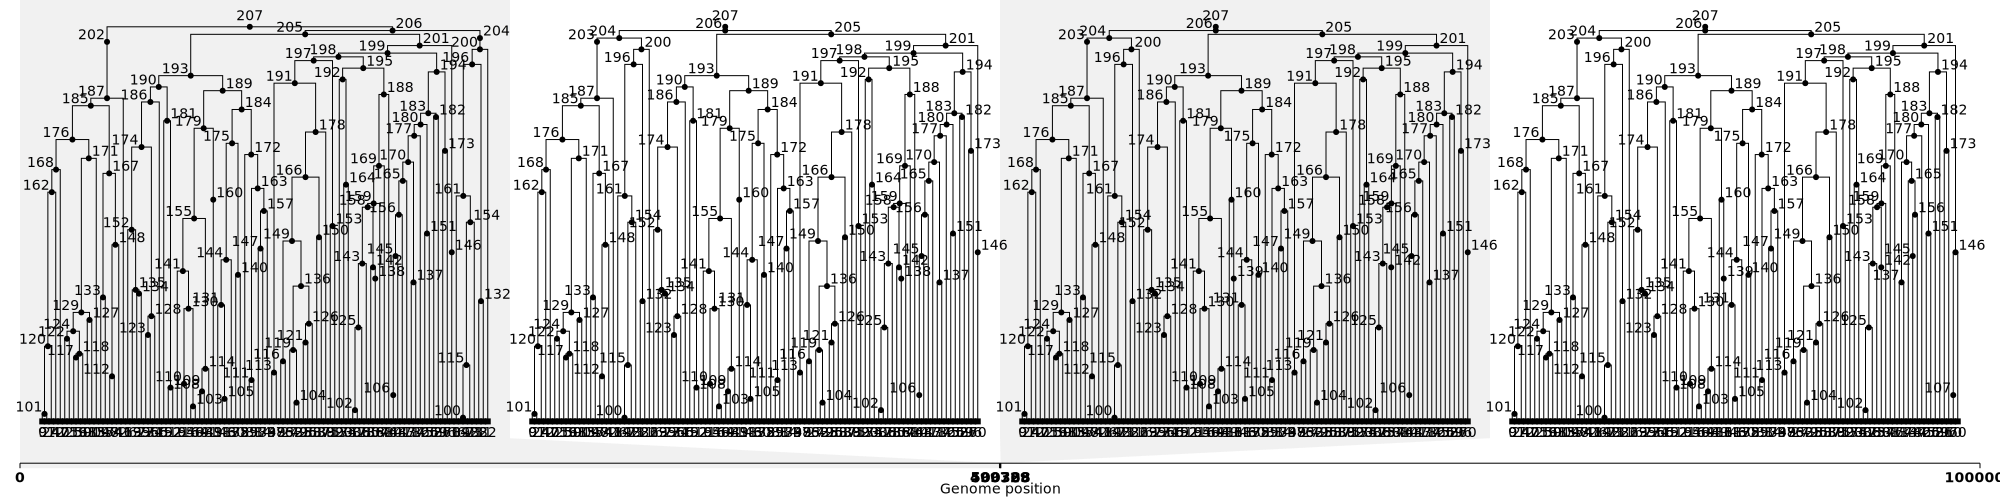

In [7]:
# Generate msprime sim
rate_map = msprime.RateMap(
    position=[0, 495000, 505000, 1000000],
    rate=[0, 1e-5, 0]
)
seed =   358275.01148411 #np.random.uniform(1,1000000,1)
ts = msprime.sim_ancestry(
    50, recombination_rate=rate_map, sequence_length=1e6, random_seed=int(seed), record_full_arg=True, model='smc', stop_at_local_mrca=False)
ts.draw_svg(size=(2000,500), time_scale='rank')

In [8]:
mts = add_mutations(ts)

In [ ]:

# 2. Run Relate on the full tree sequence
relate_utils.run_relate(
    ts,
    recombination_rate=1e-8,
    mutation_rate=1.25e-8,
    Ne=50,            # diploid — converted to haploid internally
    relate_loc="../",
    filename="my_sim",
    threads=1,
    memory=16,
)


In [ ]:
# 3. Map all mutations to the 10kb hotspot region + 5kb on each side,
site_ids = relate_utils.map_mutations_to_region(ts, start_pos=490000, end_pos=510000)

# 4. Build the genotype matrix
genotype_matrix, site_positions = relate_utils.get_genotype_matrix(ts, site_ids)
# genotype_matrix shape: (num_mapped_sites x num_samples)